# Statistical Analytic Methods
#### Prof. KKIM, Yonsei University
### LEC05. Descriptive Statistics

#### Practice 1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
salary_df = pd.read_csv('/content/drive/MyDrive/[YU]/[Lecture]/[SAM]/01_SAM_Practice/SAM_LEC05/technova_salaries.csv')
adm_df = pd.read_csv('/content/drive/MyDrive/[YU]/[Lecture]/[SAM]/01_SAM_Practice/SAM_LEC05/ucbadmin.csv')

In [ ]:
# P1. I read an article saying startup's 'average' salary is over $100k.
# But most employees make around $50k-$60k. Explain why.
mean_salary = salary_df['Salary_USD'].mean()
median_salary = salary_df['Salary_USD'].median()
print(f"Mean Salary: ${mean_salary:,.2f}")
print(f"Median Salary: ${median_salary:,.2f}")
# The mean salary is much higher than the median salary because a small number
# of employees have extremely high salaries. These high salaries pull the mean
# upward, while the median is less affected by extreme values.

# Mean is heavily pulled by outliers, Median represents the typical employee.

Mean Salary: $108,102.65
Median Salary: $54,568.50


In [ ]:
mode_salary = salary_df['Salary_USD'].mode()
print(f"Mode Salary: ${mode_salary.iloc[0]:,.2f}")

Mode Salary: $53,127.00


<Axes: xlabel='Salary_USD', ylabel='Count'>

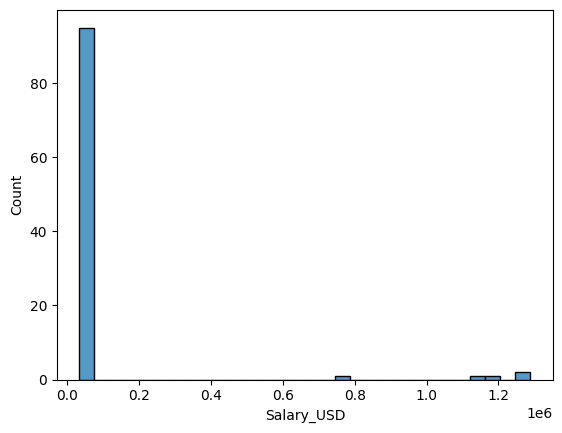

In [ ]:
# P2. Draw a histogram of the company's salaries. Based on your Mean and Median from
# Q1 and the shape of the chart, tell me exactly if our salary distribution is
# Positively Skewed or Negatively Skewed.
# plt.figure(figsize=(8, 5))
sns.histplot(salary_df['Salary_USD'], bins=30, kde=False)
# plt.title('Salary Distribution (Positive/Right Skew)')
# plt.xlabel('Salary (USD)')
# plt.show()

# The tail extends to the right (Positive Skew). Mean > Median.


In [ ]:
# P3. Find the maximum salary in the dataset. Remove outliers (salaries over $300k)
# and recalculate the Mean and Median. How do the central tendency measures change?
max_salary = salary_df['Salary_USD'].max()
print(f"Max Salary: ${max_salary:,.2f}")

filtered_df = salary_df[salary_df['Salary_USD'] <= 300000]
new_mean = filtered_df['Salary_USD'].mean()
new_median = filtered_df['Salary_USD'].median()
print(f"New Mean (w/o outliers): ${new_mean:,.2f}")
print(f"New Median (w/o outliers): ${new_median:,.2f}")

# Without extreme values, Mean and Median become almost identical (Symmetric).

Max Salary: $1,288,836.00
New Mean (w/o outliers): $54,221.14
New Median (w/o outliers): $53,894.00


In [ ]:
# P4. We need to order company hoodies. Since hoodie sizes are categorical data,
# find the Mode of the Hoodie_Size column to determine the most common size.
salary_df['Hoodie_Size'].value_counts()

,count
Hoodie_Size,
L,46
S,28
M,17
XL,9


In [ ]:
most_common_size = salary_df['Hoodie_Size'].mode()[0]
print(f"Most common hoodie size (Mode): {most_common_size}")

Most common hoodie size (Mode): L


In [ ]:
# P5. Calculate the overall admission rates for Male and Female applicants.
# Is the overall admission rate higher for men?
adm_df.head()

,Admit,Gender,Dept,n
0,Admitted,Male,A,512
1,Rejected,Male,A,313
2,Admitted,Female,A,89
3,Rejected,Female,A,19
4,Admitted,Male,B,353


In [ ]:
total_by_gender = (
    adm_df.groupby('Gender')['n']
    .sum()
    .reset_index()
    .rename(columns={'n': 'Total'})
)
total_by_gender

In [ ]:
admitted_by_gender = (
    adm_df[adm_df['Admit'] == 'Admitted']
    .groupby('Gender')['n']
    .sum()
    .reset_index()
    .rename(columns={'n': 'Admitted'})
)
admitted_by_gender

,Gender,Admitted
0,Female,557
1,Male,1198


In [ ]:
overall_admit = total_by_gender.merge(
    admitted_by_gender,
    on='Gender',
    how='left'
)
overall_admit

,Gender,Total,Admitted
0,Female,1835,557
1,Male,2691,1198


In [ ]:
overall_admit['Admit_Percentage'] = (
    overall_admit['Admitted'] / overall_admit['Total'] * 100
)
overall_admit

,Gender,Total,Admitted,Admit_Percentage
0,Female,1835,557,30.354223
1,Male,2691,1198,44.518766


In [ ]:
# P6. Calculate the admission rates for Men and Women within each department.
# Visualize the results using a bar chart.
# Explain why the department-level admission patterns differ from the overall
# admission pattern found above.
dept_total = (
    adm_df.groupby(['Dept', 'Gender'])['n']
    .sum()
    .reset_index()
    .rename(columns={'n': 'Total'})
)
dept_total

,Dept,Gender,Total
0,A,Female,108
1,A,Male,825
2,B,Female,25
3,B,Male,560
4,C,Female,593
5,C,Male,325
6,D,Female,375
7,D,Male,417
8,E,Female,393
9,E,Male,191


In [ ]:
dept_admitted = (
    adm_df[adm_df['Admit'] == 'Admitted']
    .groupby(['Dept', 'Gender'])['n']
    .sum()
    .reset_index()
    .rename(columns={'n': 'Admitted'})
)
dept_admitted

,Dept,Gender,Admitted
0,A,Female,89
1,A,Male,512
2,B,Female,17
3,B,Male,353
4,C,Female,202
5,C,Male,120
6,D,Female,131
7,D,Male,138
8,E,Female,94
9,E,Male,53


In [ ]:
dept_merged = pd.merge(
    dept_total,
    dept_admitted,
    on=['Dept', 'Gender'],
    how='left'
)
dept_merged

,Dept,Gender,Total,Admitted
0,A,Female,108,89
1,A,Male,825,512
2,B,Female,25,17
3,B,Male,560,353
4,C,Female,593,202
5,C,Male,325,120
6,D,Female,375,131
7,D,Male,417,138
8,E,Female,393,94
9,E,Male,191,53


In [ ]:
dept_merged['Admit_Percentage'] = (
    dept_merged['Admitted'] / dept_merged['Total'] * 100
)
dept_merged

,Dept,Gender,Total,Admitted,Admit_Percentage
0,A,Female,108,89,82.407407
1,A,Male,825,512,62.060606
2,B,Female,25,17,68.000000
3,B,Male,560,353,63.035714
4,C,Female,593,202,34.064081
5,C,Male,325,120,36.923077
6,D,Female,375,131,34.933333
7,D,Male,417,138,33.093525
8,E,Female,393,94,23.918575
9,E,Male,191,53,27.748691


<Axes: xlabel='Dept', ylabel='Admit_Percentage'>

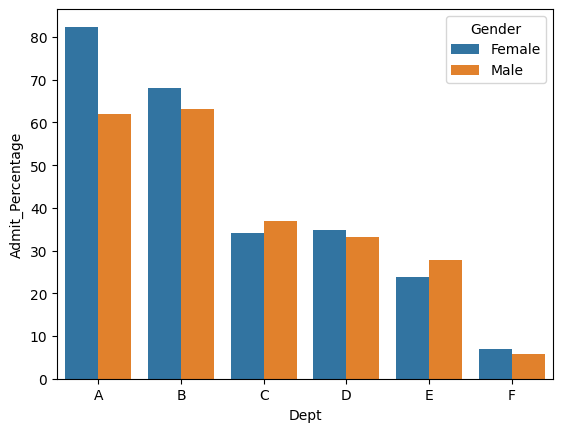

In [ ]:
sns.barplot(
    data=dept_merged,
    x='Dept',
    y='Admit_Percentage',
    hue='Gender'
)

#### Practice 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/[YU]/[Lecture]/[SAM]/01_SAM_Practice/SAM_LEC05/battery_production.csv')
df.head()

,Product_ID,Factory,Battery_Life_Hours
0,BAT_0001,A,24.248357
1,BAT_0002,A,23.930868
2,BAT_0003,A,24.323844
3,BAT_0004,A,24.761515
4,BAT_0005,A,23.882923


In [ ]:
# P1. Both Factory A and Factory B claim their average battery
# life is around 24 hours. However, we need a supplier we can trust.
# Which factory produces a more "consistent" battery life? Prove it with numbers.
consistency = df.groupby('Factory')['Battery_Life_Hours'].std()
print("Standard Deviation by Factory:")
print(consistency)
# Factory A has lower Std.dev -> more consistency

Standard Deviation by Factory:
Factory
A    0.489608
B    1.820540
Name: Battery_Life_Hours, dtype: float64


In [ ]:
# P2. The engineering team assumes our battery
# life follows a normal distribution. If so, roughly 68% of the batteries should
# fall within one standard deviation from the average. Can you check if Factory
# A's products actually meet this 68% rule?
factory_a_df = df[df['Factory'] == 'A']
mean_a = factory_a_df['Battery_Life_Hours'].mean()
std_a = factory_a_df['Battery_Life_Hours'].std()

lower_bound = mean_a - std_a
upper_bound = mean_a + std_a

within_1_std = factory_a_df[(factory_a_df['Battery_Life_Hours'] >= lower_bound) &
                            (factory_a_df['Battery_Life_Hours'] <= upper_bound)]
percentage = (len(within_1_std) / len(factory_a_df)) * 100

print(f"Mean: {mean_a:.2f}")
print(f"Standard Deviation: {std_a:.2f}")
print(f"Range: {lower_bound:.2f} ~ {upper_bound:.2f}")
print(f"Percentage within 1 SD: {percentage:.2f}%")
# About 68.6% of Factory A's batteries fall within one standard deviation of the mean.
# This is close to the 68% expected under a normal distribution.

Mean: 24.01
Standard Deviation: 0.49
Range: 23.52 ~ 24.50
Percentage within 1 SD: 68.60%


In [ ]:
# P3. Catching the Outliers (Z-score): We must catch extreme defects before shipping.
# Calculate the standardized scores (Z-score) for all batteries.
# How many batteries from Factory B are considered strictly 'out of control'
# (meaning their score falls outside the $\pm 3$ range)?

# Z = (X - Mean) / Std
df['Z_score'] = (df['Battery_Life_Hours'] - df['Battery_Life_Hours'].mean()) / df['Battery_Life_Hours'].std()

# B공장에서 Z-score 절대값이 3을 초과하는 불량품 개수
outliers_b = df[(df['Factory'] == 'B') & (abs(df['Z_score']) > 3)]
print(f"Number of 'out of control' batteries in Factory B: {len(outliers_b)}")

Number of 'out of control' batteries in Factory B: 26


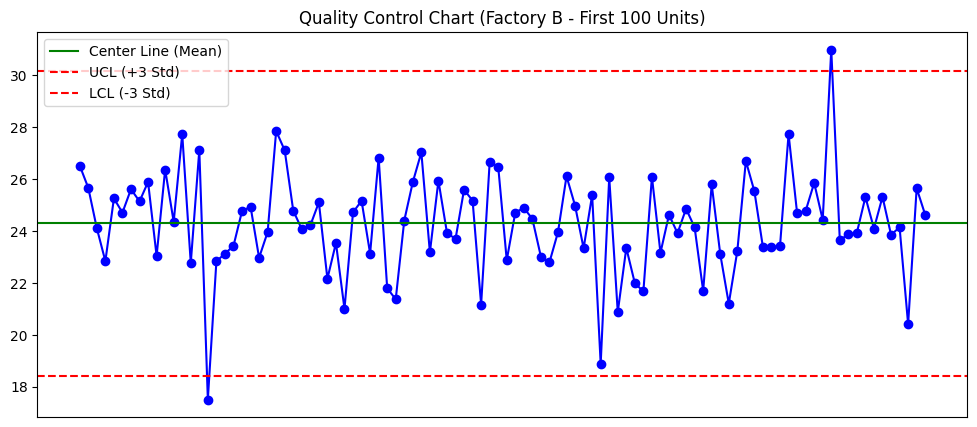

In [ ]:
# P4. Create a Line Chart (Control Chart) for the first 100 batteries from Factory B.
# Plot the battery life, and draw three clear horizontal lines: the Center Line (Average),
# the Upper Control Limit, and the Lower Control Limit.
# (Hint: The control limits are exactly 3 standard deviations away from the mean!)

sample_b = df[df['Factory'] == 'B'].head(100).copy()

mean_all = df['Battery_Life_Hours'].mean()
std_all = df['Battery_Life_Hours'].std()

UCL = mean_all + 3 * std_all
LCL = mean_all - 3 * std_all

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=sample_b,
    x='Product_ID',
    y='Battery_Life_Hours',
    marker='o'
)

plt.axhline(mean_all, linestyle='-', label='Center Line (Mean)')
plt.axhline(UCL, linestyle='--', label='UCL (+3 SD)')
plt.axhline(LCL, linestyle='--', label='LCL (-3 SD)')
plt.xticks([])
plt.show()

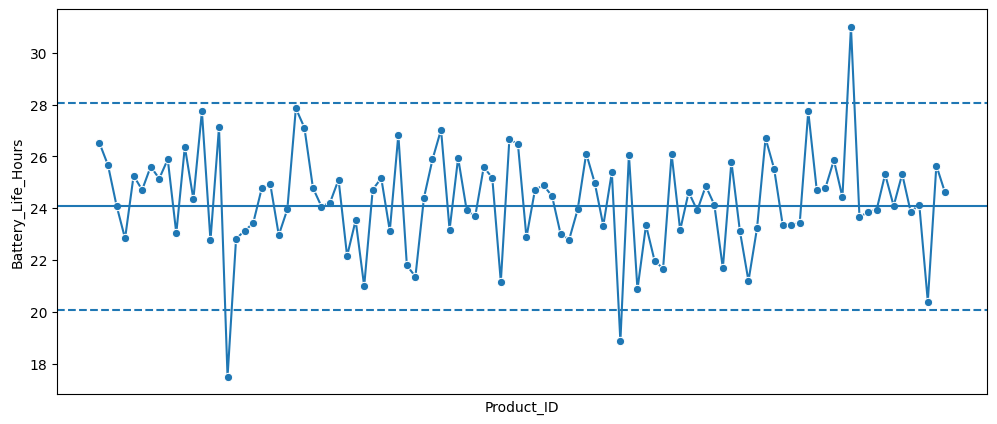